In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

import matplotlib.pyplot as plt
%matplotlib inline
import neurobayes as nb
import numpy as np

import sys
sys.path.append('..')  # Add parent directory to path

from utils.data_loading import load_dataset
from utils.styles import apply_style, OKABE_ITO

In [21]:
x, y = load_dataset('../input', file_pattern='data_{}.npy', n_files=1000)


# x = np.array(x)
# y = np.array(y)

norm = y.max()
# NormalizaÃ§Ã£o
y /= y.max()


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.25)

Loading data: 100%|██████████| 1000/1000 [00:00<00:00, 3160.07it/s]


In [22]:

X_train_flat = x_train.reshape(x_train.shape[0], -1)
X_val_flat = x_test.reshape(x_test.shape[0], -1)


architecture = nb.FlaxMLP(
    hidden_dims=[16, 16],
    target_dim=1,
    # hidden_dropout=0.1
)


bnn = nb.BNN(architecture)



In [23]:

bnn.fit(
    X_train_flat, y_train
)

sample: 100%|██████████| 4000/4000 [28:50<00:00,  2.31it/s, 1023 steps of size 3.13e-06. acc. prob=0.66]


In [24]:

mean_pred, var_pred = bnn.predict(X_val_flat)
std_pred = np.sqrt(var_pred)

for i in range(5):
    print(f"Predição: {mean_pred[i][0]:.2f} ± {std_pred[i][0]:.2f}")

Predição: 0.90 ± 0.00
Predição: 0.93 ± 0.00
Predição: 0.93 ± 0.00
Predição: 0.84 ± 0.00
Predição: 0.93 ± 0.00


In [25]:
# Calculate metrics
mean_pred_flat = mean_pred.flatten()
std_pred_flat = std_pred.flatten()

r2 = r2_score(y_test, mean_pred_flat)
mse = mean_squared_error(y_test, mean_pred_flat)
mae = mean_absolute_error(y_test, mean_pred_flat)
rmse = root_mean_squared_error(y_test, mean_pred_flat)

print(f"BNN Performance Metrics")
print(f"{'='*40}")
print(f"R² Score:  {r2:.4f}")
print(f"MSE:       {mse:.6f}")
print(f"MAE:       {mae:.4f}")
print(f"RMSE:      {rmse:.4f}")
print(f"{'='*40}")
print(f"\nMean prediction uncertainty: {std_pred_flat.mean():.4f}")

BNN Performance Metrics
R² Score:  0.9990
MSE:       0.000003
MAE:       0.0015
RMSE:      0.0018

Mean prediction uncertainty: 0.0019


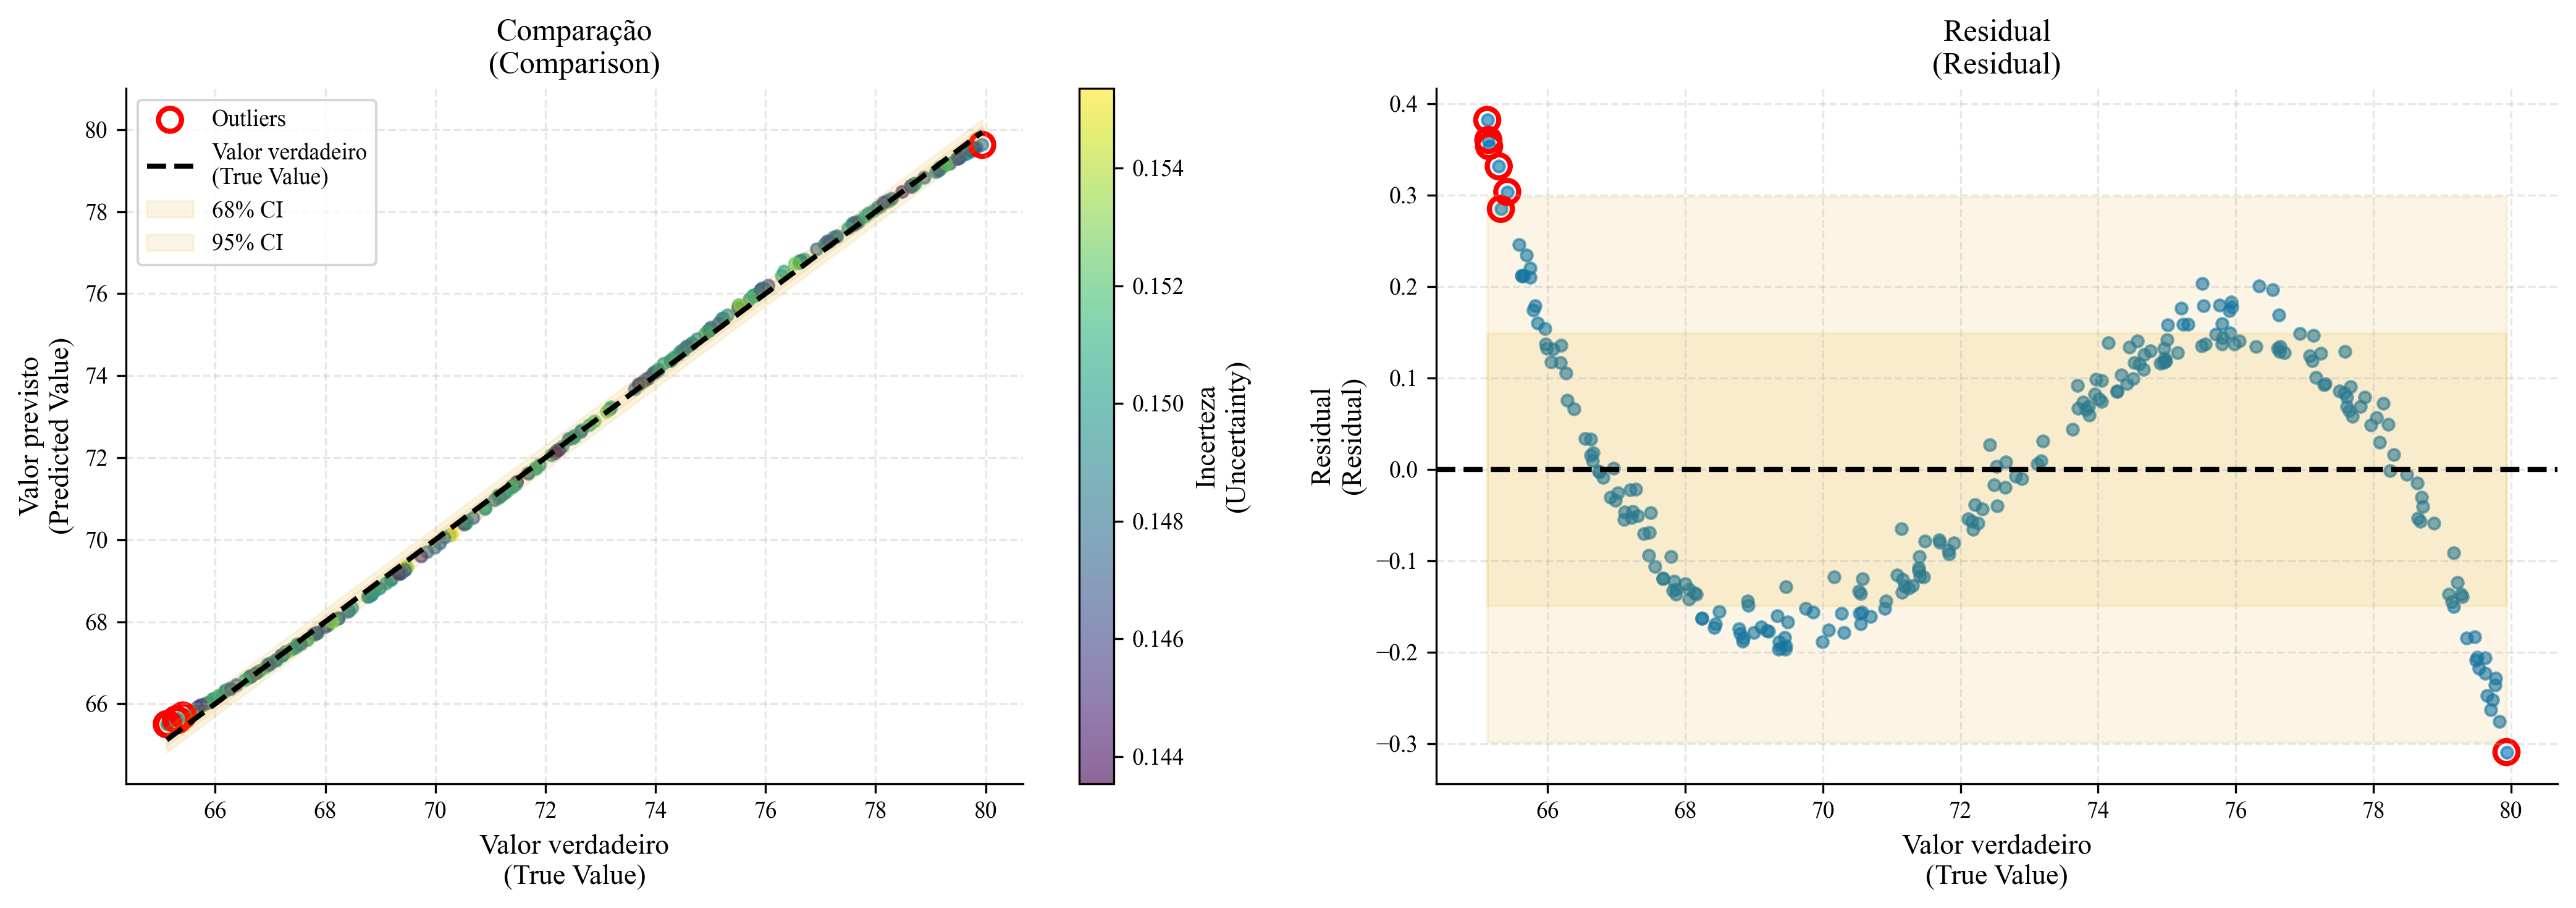

In [37]:
# Plot predictions with uncertainty (compatible with utils)
from utils.visualization import plot_predictions_enhanced

# Scale back to original units for interpretation
y_test_orig = y_test * norm
mean_pred_orig = mean_pred_flat * norm
std_pred_orig = std_pred_flat * norm

fig = plot_predictions_enhanced(
    y_true=y_test_orig,
    y_pred=mean_pred_orig,
    y_std=std_pred_orig,
    show_intervals=(68, 95),
    color_by='density',
    highlight_outliers=True,
    outlier_threshold=2,
    language='both',
    save_path='../imagens/bnn_predictions.png'
)

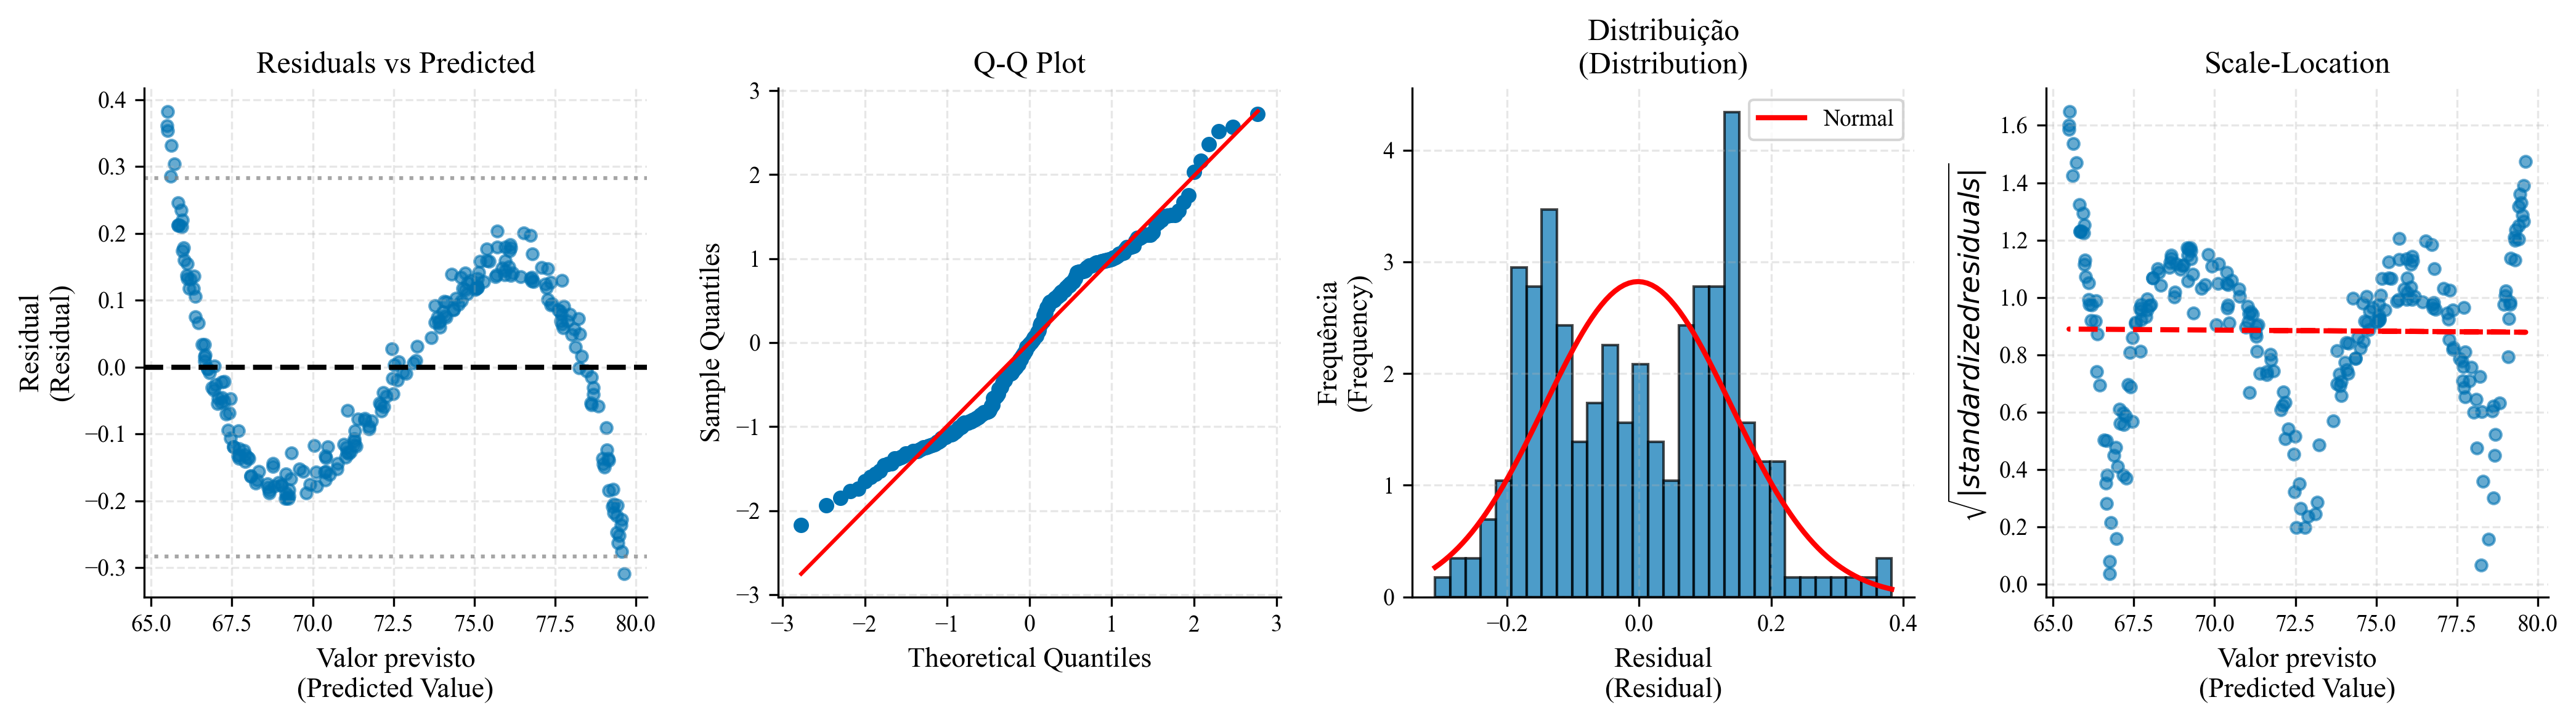

In [27]:
# Residual diagnostics
from utils.visualization import plot_residual_diagnostics

fig = plot_residual_diagnostics(
    y_true=y_test_orig,
    y_pred=mean_pred_orig,
    language='both',
    save_path='../imagens/bnn_residuals.png'
)

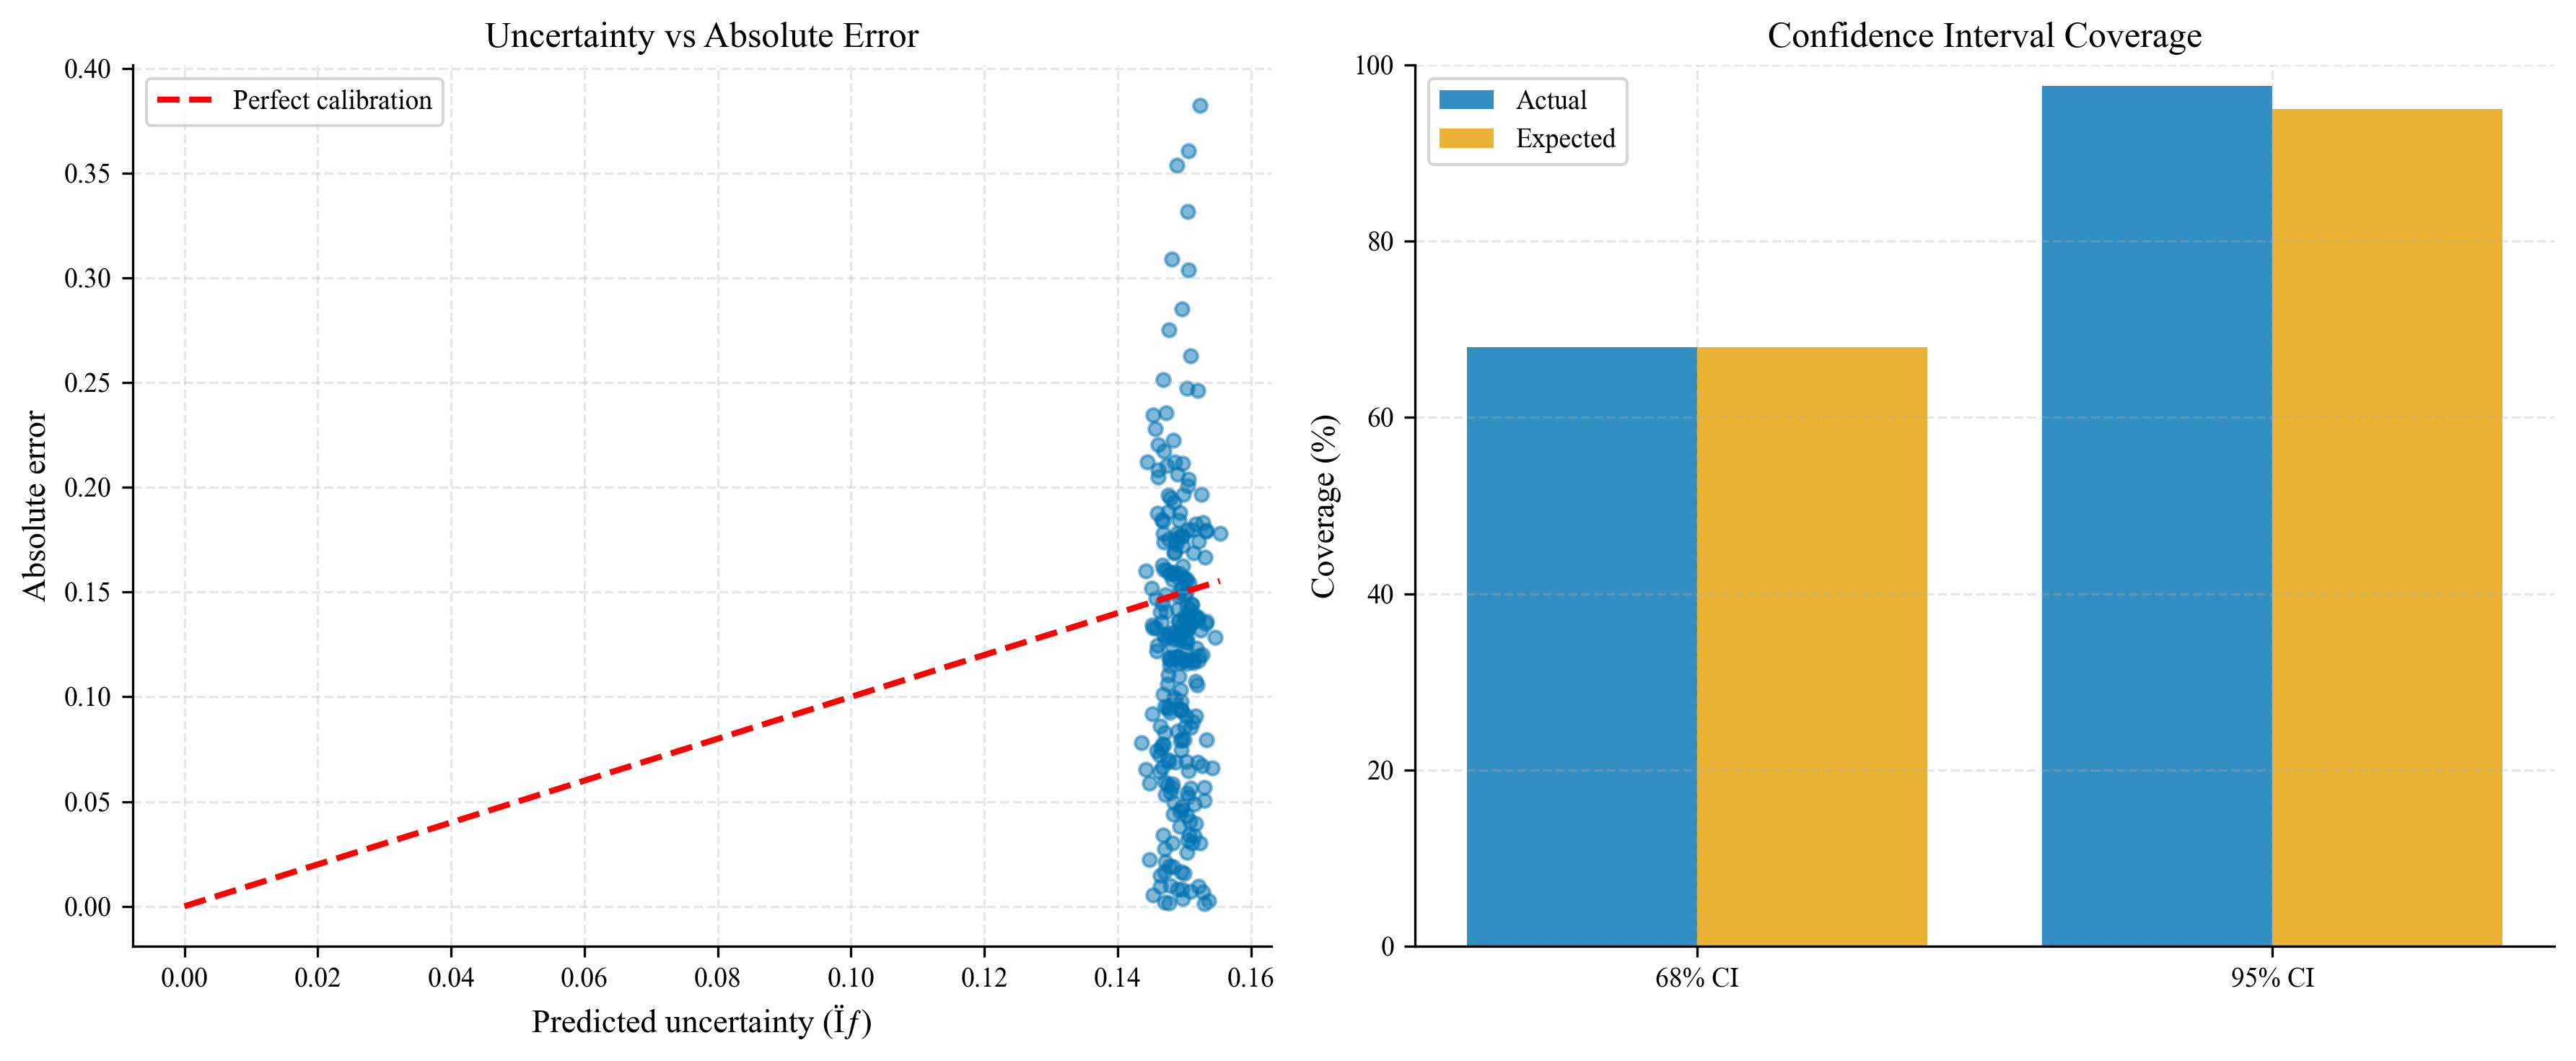


Uncertainty Calibration:
68% CI coverage: 68.0% (expected: 68%)
95% CI coverage: 97.6% (expected: 95%)


In [28]:
# Uncertainty calibration plot
apply_style('academic')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Uncertainty vs absolute error
ax = axes[0]
abs_error = np.abs(y_test_orig - mean_pred_orig)
ax.scatter(std_pred_orig, abs_error, alpha=0.5, s=20, color=OKABE_ITO[0])
ax.plot([0, std_pred_orig.max()], [0, std_pred_orig.max()], 'r--', linewidth=2, label='Perfect calibration')
ax.set_xlabel('Predicted uncertainty (Ïƒ)', fontsize=11)
ax.set_ylabel('Absolute error', fontsize=11)
ax.set_title('Uncertainty vs Absolute Error', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Coverage plot
ax = axes[1]
coverage_68 = np.sum(abs_error <= std_pred_orig) / len(abs_error) * 100
coverage_95 = np.sum(abs_error <= 2 * std_pred_orig) / len(abs_error) * 100

bars = ['68% CI', '95% CI']
coverage = [coverage_68, coverage_95]
expected = [68, 95]

x_pos = np.arange(len(bars))
ax.bar(x_pos - 0.2, coverage, 0.4, label='Actual', color=OKABE_ITO[0], alpha=0.8)
ax.bar(x_pos + 0.2, expected, 0.4, label='Expected', color=OKABE_ITO[1], alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(bars)
ax.set_ylabel('Coverage (%)', fontsize=11)
ax.set_title('Confidence Interval Coverage', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../imagens/bnn_uncertainty_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nUncertainty Calibration:")
print(f"68% CI coverage: {coverage_68:.1f}% (expected: 68%)")
print(f"95% CI coverage: {coverage_95:.1f}% (expected: 95%)")

## Feature Importance Analysis

Analyze which redshift (z) values contribute most to BNN predictions.
Since BNN input is flattened (80 z-points x 2 features = 160), we analyze
importance per z-point by shuffling H(z) values.

In [29]:
def calculate_bnn_redshift_importance(bnn, X, y, n_renn=5, random_state=42):
    """
    Calculate feature importance for BNN by z-point.
    
    Since input is flattened, we group features by z-point:
    - Feature 0-79: z values (not shuffled, just for reference)
    - Feature 80-159: H(z) values (shuffled to break relationship)
    
    For each z-point, we shuffle its H(z) values across all samples.
    """
    n_samples, n_features = X.shape
    n_z_points = n_features // 2  # 80 z-points
    
    # Get baseline prediction
    mean_pred, _ = bnn.predict(X)
    baseline_mse = np.mean((y.flatten() - mean_pred.flatten()) ** 2)
    
    importances = np.zeros(n_z_points)
    uncertainties = np.zeros(n_z_points)
    
    # Get z values from first sample (assuming same z for all)
    # z values are at indices 0, 2, 4, ... (every other feature starting at 0)
    z_indices = np.arange(0, n_features, 2)
    h_indices = np.arange(1, n_features, 2)  # H(z) at indices 1, 3, 5, ...
    
    redshifts = X[0, z_indices]  # Extract z values
    
    for i in range(n_z_points):
        feature_importances = []
        
        for r in range(n_renn):
            X_shuffled = X.copy()
            np.random.seed(random_state + i * n_renn + r)
            
            # Shuffle H(z) values for this z-point across samples
            np.random.shuffle(X_shuffled[:, h_indices[i]])
            
            mean_shuffled, _ = bnn.predict(X_shuffled)
            shuffled_mse = np.mean((y.flatten() - mean_shuffled.flatten()) ** 2)
            
            feature_importances.append(shuffled_mse - baseline_mse)
        
        importances[i] = np.mean(feature_importances)
        uncertainties[i] = np.std(feature_importances)
    
    # Normalize
    total = np.sum(importances)
    if total > 0:
        importances /= total
        uncertainties /= total
    
    return {
        'importances': importances,
        'uncertainties': uncertainties,
        'redshifts': redshifts,
        'baseline_mse': baseline_mse
    }

In [30]:
# Calculate feature importance (using smaller subset for speed with MCMC)
print("Calculating BNN feature importance...")
print("(This uses 5 shuffles per z-point - may take a few minutes)")

# Use subset for faster computation
n_subset = 200
subset_idx = np.random.choice(len(X_val_flat), n_subset, replace=False)
X_subset = X_val_flat[subset_idx]
y_subset = y_test[subset_idx]

bnn_importance = calculate_bnn_redshift_importance(
    bnn, X_subset, y_subset.reshape(-1, 1),
    n_renn=5,
    random_state=42
)
print(f"Done! Baseline MSE: {bnn_importance['baseline_mse']:.6f}")

Calculating BNN feature importance...
(This uses 5 shuffles per z-point - may take a few minutes)
Done! Baseline MSE: 0.000003


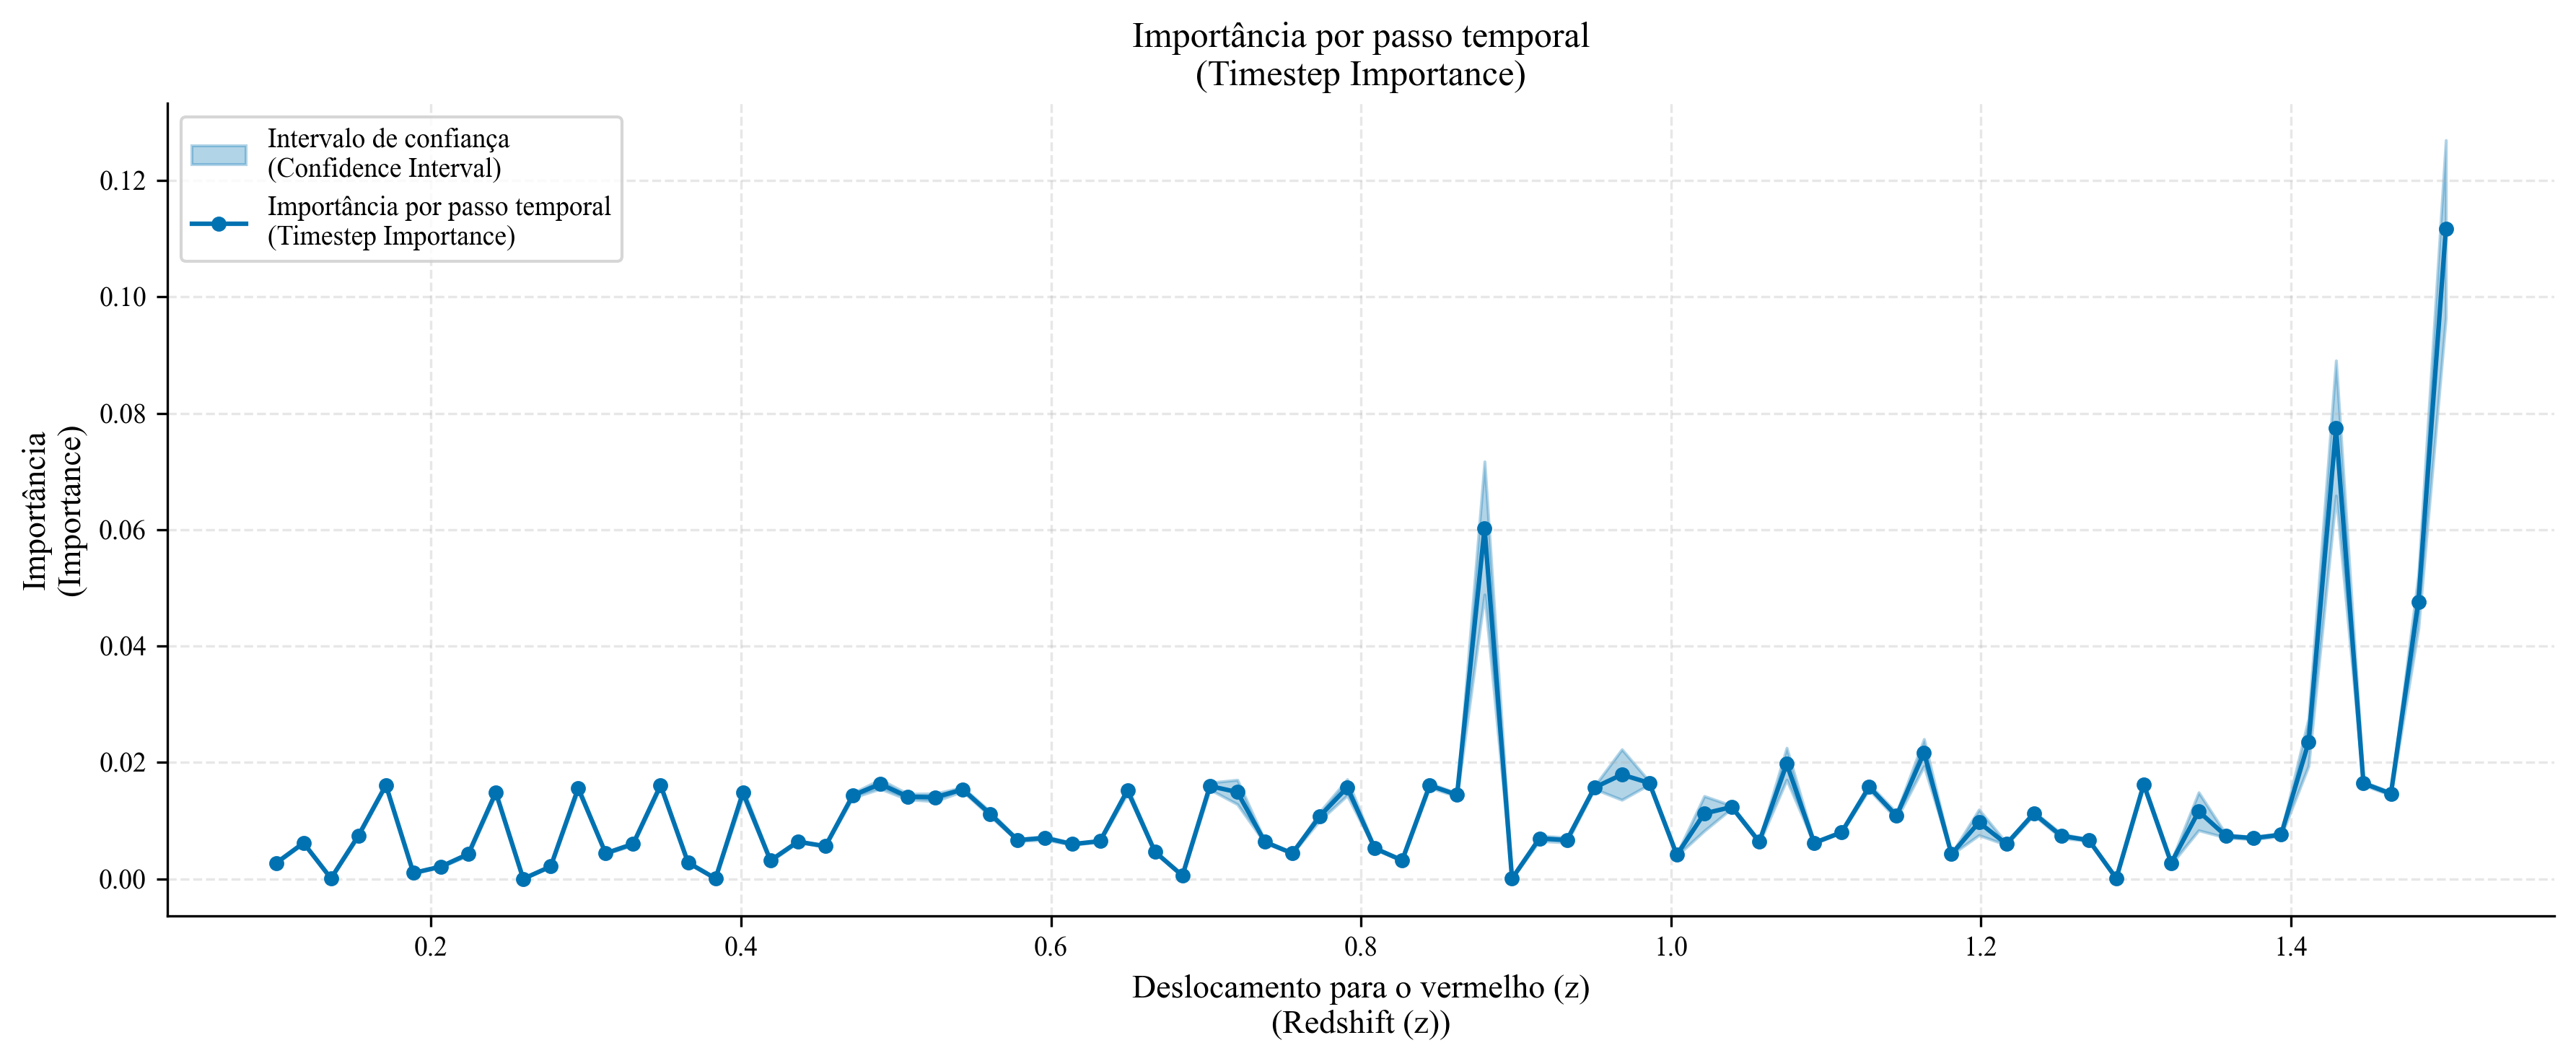

In [31]:
# Plot feature importance using utils visualization
from utils.visualization import plot_timestep_importance_enhanced

apply_style('academic')

fig = plot_timestep_importance_enhanced(
    importances=bnn_importance['importances'],
    uncertainties=bnn_importance['uncertainties'],
    redshifts=bnn_importance['redshifts'],
    show_confidence=True,
    show_theory=False,
    theory_model='LCDM',
    language='both',
    save_path='../imagens/bnn_feature_importance.png'
)

In [32]:
# Show top 10 most important z-points
sorted_idx = np.argsort(bnn_importance['importances'])[::-1]
print("Top 10 redshift points by importance:")
print("-" * 45)
for rank, idx in enumerate(sorted_idx[:10], 1):
    z = bnn_importance['redshifts'][idx]
    imp = bnn_importance['importances'][idx]
    unc = bnn_importance['uncertainties'][idx]
    print(f"{rank:2d}. z = {z:6.3f}  |  Importance: {imp:.4f} +/- {unc:.4f}")

Top 10 redshift points by importance:
---------------------------------------------
 1. z =  1.500  |  Importance: 0.1117 +/- 0.0152
 2. z =  1.429  |  Importance: 0.0775 +/- 0.0116
 3. z =  0.880  |  Importance: 0.0603 +/- 0.0114
 4. z =  1.482  |  Importance: 0.0476 +/- 0.0047
 5. z =  1.411  |  Importance: 0.0235 +/- 0.0041
 6. z =  1.163  |  Importance: 0.0217 +/- 0.0023
 7. z =  1.075  |  Importance: 0.0198 +/- 0.0027
 8. z =  0.968  |  Importance: 0.0179 +/- 0.0043
 9. z =  0.986  |  Importance: 0.0165 +/- 0.0003
10. z =  1.447  |  Importance: 0.0164 +/- 0.0003


In [33]:
# forecasting "real" H(0)
# Note: BNN expects flattened input (same as training)
real = np.load('../input/data_real80.npy')
real = real[real[:, 1].argsort()]
real = real.reshape(-1, 160)  # Flatten for BNN input

In [34]:
mean_pred, var_pred = bnn.predict(real)
std_pred = np.sqrt(var_pred)


print(f"Predição: {mean_pred[0][0]*norm:.2f} ± {std_pred[0][0]*norm:.2f}")

Predição: 67.35 ± 0.14


In [35]:
mean_pred, var_pred

(Array([[0.8421934]], dtype=float32), Array([[3.2770095e-06]], dtype=float32))